In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


 IRRIGATION NEED PREDICTION USING XGBOOST
 Goal: Predict whether irrigation need is Low / Medium / High


In [16]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

# pandas -> for loading and manipulating tabular data
import pandas as pd

# train_test_split -> split training data into train + validation
from sklearn.model_selection import train_test_split

# LabelEncoder -> convert target labels (Low/Medium/High) into numbers
from sklearn.preprocessing import LabelEncoder

# Metrics to evaluate model performance
from sklearn.metrics import accuracy_score, classification_report

# XGBoost model (powerful for structured/tabular data)
from xgboost import XGBClassifier

# matplotlib -> for plotting feature importance graph
import matplotlib.pyplot as plt



# =========================
# 1. LOAD DATA
# =========================
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
# Save test IDs separately
# Needed later when creating Kaggle submission file
test_ids = test['id']
# 'id' is just an identifier
# It does NOT help predict irrigation need
train = train.drop(columns=['id'])
test = test.drop(columns=['id'])



Create new useful features from existing columns
This helps model capture hidden patterns

In [17]:
# =========================
# 2. FEATURE ENGINEERING
# =========================
# Water_Balance:
    # Total available water =
    # rainfall + previous irrigation
# Temp_Humidity:
    # High temperature + humidity affects
    # evaporation and irrigation need
# Moisture_Index:
    # Combines soil moisture and humidity
    # to estimate overall wetness
for df in [train, test]:
    df['Water_Balance'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Temp_Humidity'] = df['Temperature_C'] * df['Humidity']
    df['Moisture_Index'] = df['Soil_Moisture'] * df['Humidity']








In [18]:
# =========================
# 3. ENCODE TARGET
# =========================
# Machine learning models need numbers,
# not text labels like "Low", "Medium", "High"
le = LabelEncoder()
train['Irrigation_Need'] = le.fit_transform(train['Irrigation_Need'])


In [19]:
# =========================
# 4. SPLIT FEATURES
# =========================
# X = input features
# y = output label to predict
X = train.drop('Irrigation_Need', axis=1)
y = train['Irrigation_Need']


In [20]:
# =========================
# 5. ENCODE CATEGORICALS
# =========================
# Columns like Soil_Type, Crop_Type are text.
# Convert them into numerical format using one-hot encoding.
X = pd.get_dummies(X)
test = pd.get_dummies(test)

# Ensure train and test have EXACT same columns
# Missing columns in test are filled with 0
X, test = X.align(test, join='left', axis=1, fill_value=0)



In [21]:
# =========================
# 6. TRAIN / VALIDATION SPLIT
# =========================

# Split training data:
# 80% -> model learns
# 20% -> model is tested

# stratify=y keeps class proportions balanced
# random_state makes results reproducible
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [22]:
# =========================
# 7. XGBOOST MODEL
# =========================
# XGBoost is powerful for structured datasets

model = XGBClassifier(

    # Number of trees
    n_estimators=300,

    # Maximum depth of each tree
    max_depth=8,

    # Learning speed
    learning_rate=0.1,

    # Randomly use 80% rows per tree
    # helps prevent overfitting
    subsample=0.8,

    # Randomly use 80% columns per tree
    colsample_bytree=0.8,

    # Multi-class classification
    objective='multi:softmax',

    # 3 classes:
    # Low / Medium / High
    num_class=3,

    # Evaluation metric
    eval_metric='mlogloss',

    # Faster training for large data
    tree_method='hist',

    # Reproducibility
    random_state=42
)

# Learn patterns from training data

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [23]:
# =========================
# 8. EVALUATION
# =========================

# Predict on unseen validation data
y_pred = model.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

# Detailed class performance:
# precision, recall, f1-score
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Validation Accuracy: 0.9853650793650793

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



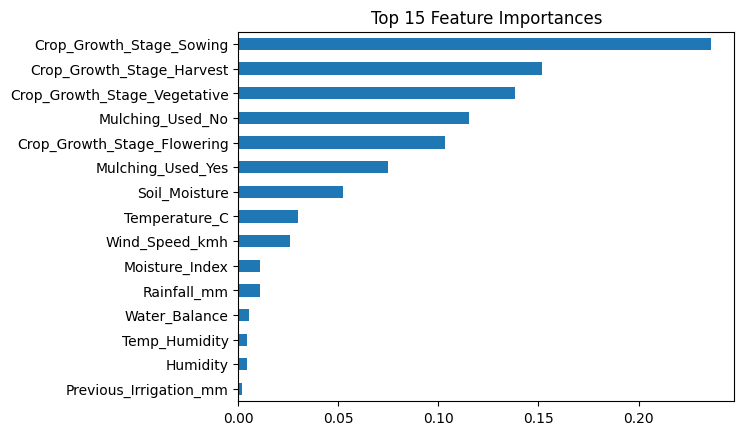

In [24]:

# =========================
# 9. FEATURE IMPORTANCE
# =========================
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure()
importances.plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()




In [25]:
# =========================
# 10. TRAIN ON FULL DATA
# =========================
model.fit(X, y)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [26]:
# =========================
# 11. PREDICT TEST
# =========================
test_preds = model.predict(test)
test_preds = le.inverse_transform(test_preds)



In [27]:
# =========================
# 12. SUBMISSION FILE
# =========================
submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': test_preds
})

submission.to_csv('submission.csv', index=False)

print("Submission file created!")

Submission file created!
